# Assignment 5 — Systematic Swiss Equity Strategy
**A Risk-Based Core with a Machine-Learning Defensive Tilt**

Deadline: 30.06.2026, 12:00 CEST

**Submitted by:** Luca Francesco Besomi, 20-206-769, lucafrancesco.besomi@uzh.ch; Francesco Carlo Filippo Orsingher, 21-986-971, francescocarlofilippo.orsingher@uzh.ch; Devin Liam Rohr, 16-454-753, devinliam.rohr@uzh.ch; Tamas Terner, 19-755-495, tamas.terner@uzh.ch

**Backtest window:** 2003-2022, monthly rebalancing

**Benchmark:** Swiss Performance Index (SPI)

**Costs:** 1% per year fixed + 0.2% of turnover per rebalancing (applied net throughout)

---

### Strategy thesis

In a universe this small (70-80 names a month after filtering), trying to
forecast which stocks will go up is a losing game. Expected-return
forecasts are noisy in small cross-sections, and Chopra and Ziemba (1993)
showed that errors in expected returns destroy roughly 10x more portfolio
utility than errors in risk estimates. So we don't build the strategy
around a return forecast.

Instead the core is a long-only minimum-variance portfolio on a shrunk
covariance matrix. This leans into the low-volatility anomaly: low-vol
stocks have historically had better risk-adjusted returns and shallower
drawdowns than the cap-weighted market, which is the opposite of what
CAPM predicts. The core never asks which stock will do best, only how
stocks move together, since that's the more stable thing to estimate
here.

On top of the core we add a defensive ML tilt: an ElasticNet model,
retrained every month strictly walk-forward, predicting a cross-sectional
rank of risk-adjusted forward returns from factor characteristics
(momentum, value, quality, profitability, investment, leverage,
accruals). Because it's regularized and trained on a rank rather than a
raw return, it acts as a soft adjustment to the core rather than its own
return engine. This is also what satisfies the ML requirement properly:
the model genuinely feeds the optimizer's expected-return input,
walk-forward and out-of-sample.

Finally, a regime overlay tracks the eigenvalue concentration of the
trailing correlation matrix, basically how "one-factor" the market has
become, and dials the tilt down whenever that spikes above its own
trailing median. The logic: when everything starts moving together, a
ranking signal has the least room to help and the most room to hurt, so
we lean back toward the defensive core exactly when it matters.

We test this as a ladder of four rungs, adding one ingredient at a time
so every change in performance has a single cause:

| Rung | Description |
|---|---|
| S0 | SPI, unmodified |
| S1 | Min-variance core only (Ledoit-Wolf constant-correlation Sigma, box + sector constraints, no signal) |
| S2 | S1 + defensive low-risk tilt |
| S3 | S1 + ElasticNet ML tilt (the required ML rung) |
| S4 | Full strategy: ML + low-risk blend, scaled by the regime overlay, with a turnover penalty |

Universe, calendar, and costs are identical across every rung, so a
difference between S2 and S3, say, can only come from the difference
between the two tilts.

### A note on honesty in reporting results

We report what the backtest actually gave us, including the parts that
didn't go the way we expected. Where something surprised us, like a
significant signal not actually improving the portfolio, we say so and
explain why, rather than reshaping the comparison until it looks cleaner.
A limitation we can explain is worth more than a number that looks good
but doesn't hold up.

### Setup

Standard imports, plus the libraries we need: scikit-learn for
covariance shrinkage, scikit-learn and xgboost for the ElasticNet and
tree-based signals, scipy for rank-correlation diagnostics, and cvxopt
for the custom optimizer's QP solver.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pickle
import os

from sklearn.covariance import LedoitWolf
from sklearn.linear_model import ElasticNetCV
from xgboost import XGBRegressor, XGBRanker
from scipy.stats import spearmanr
from cvxopt import matrix, solvers

solvers.options['show_progress'] = False
solvers.options['maxiters'] = 300

plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 130, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6,
})

NAVY, GOLD, GREY, GREEN = '#1b2a4a', '#c8a24a', '#9aa0a6', '#2e7d5b'
COLORS = {'S1': '#5b6b8c', 'S2': NAVY, 'S3': GOLD, 'S4': GREEN, 'SPI': GREY}
LABELS = {'S1': 'S1 min-var core', 'S2': 'S2 + low-risk tilt', 'S3': 'S3 + ML tilt',
          'S4': 'S4 full (ML + low-risk + regime)', 'SPI': 'SPI benchmark'}

# --- QPMwP framework imports (structural port) ---
import sys
sys.path.insert(0, os.path.join(os.pardir, 'src'))

from optimization.optimization import Optimization, Objective
from optimization.optimization_data import OptimizationData
from optimization.constraints import Constraints
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_budget_constraint,
    bibfn_box_constraints,
)

### 0. Frozen configuration

Every constraint, cost, and hyperparameter we use anywhere in the
notebook is declared once here and referenced by name from then on.
That way changing a number for a sensitivity check propagates everywhere
automatically instead of needing a hunt through the notebook for every
place it got hardcoded again.

A couple of these aren't arbitrary defaults:

- Box constraint = 10%, not 5%. We tried 5% first and it caused the
  optimizer to bounce between corner solutions every month, since small
  changes in the covariance estimate flip which names hit the cap. That
  pushed turnover above 500% a year, way too costly given our cost
  assumptions. Widening to 10% cut turnover to roughly 65-70% a year and
  actually raised net Sharpe.
- Sector band = 20%, absolute. Keeps each sector within plus or minus 20
  points of its SPI weight, so the optimizer can't just dump everything
  into one "defensive-looking" sector in-sample.
- Turnover penalty lambda = 1.0. Sized to be roughly comparable to the
  variance term at realistic covariance scales, so the optimizer doesn't
  chase noisy month-to-month wiggles in the signal or covariance.
- Regime threshold = trailing 12-month median, not a fixed number. Adapts
  to the general level of correlation instead of relying on a hand-picked
  constant that might not hold up in a different period.

In [2]:
# ---- paths ----
DATA_DIR = "../data"         # folder holding market_data.parquet, jkp_data.parquet, spi_index.csv
OUT      = "outputs"
FIG      = "figures"
os.makedirs(OUT, exist_ok=True)
os.makedirs(FIG, exist_ok=True)

# ---- backtest window ----
START = "2003-01-31"     # pre-2003 universe too thin
END   = "2022-12-31"     # post-2022 JKP tail is NA-ridden

# ---- covariance ----
COV_WINDOW_DAYS = 365 * 3   # calendar days (data has weekends!)
COV_METHOD      = "lw_cc"   # lw_cc | lw_ident | ridge | sample | single_index
RIDGE_FRAC      = 0.5       # lambda = RIDGE_FRAC * avg_var (ridge benchmark only)

# ---- selection ----
MIN_LIQUIDITY   = 250_000   # daily traded value floor (CHF), median-based screen
GAP_DAYS        = 15        # max consecutive price-gap tolerated in trailing year
MIN_NAMES       = 40        # skip rebalancing dates with too few investable names

# ---- feature set (literature-driven, frozen) ----
FEATURES = ['ret_6_1', 'ret_12_1',            # momentum
            'be_me',                            # value
            'qmj', 'qmj_growth', 'qmj_safety',  # quality
            'gp_at', 'op_at',                   # profitability
            'at_gr1',                           # investment (flip)
            'debt_me',                          # leverage  (flip)
            'oaccruals_at']                     # accruals  (flip)
SIGN_FLIP   = ['at_gr1', 'debt_me', 'oaccruals_at']
LOWRISK     = ['rvol_21d', 'ivol_capm_252d', 'beta_60m', 'betadown_252d']

# ---- optimizer ----
BOX_UPPER   = 0.10          # max weight per name (5% bounced between corners -> high turnover)
SECTOR_BAND = 0.20          # max active sector weight vs benchmark (absolute band)
GAMMA_TILT  = 0.5           # signal tilt intensity (low: risk-based core dominant)
LAMBDA_TO   = 1.0           # turnover penalty

# per-rung tilt strengths (calibrated on net Sharpe, frozen)
GAMMA_S2 = 0.5              # low-risk defensive tilt
GAMMA_S3 = 1.0              # ML expected-return tilt (required ML rung)
GAMMA_S4 = 1.0              # blend(ML + low-risk) tilt + regime overlay

# ---- ML signal ----
TRAIN_WINDOW_OBS = 60       # months of panel used for training

# ---- regime overlay (S4) ----
REGIME_LOOKBACK  = 12       # months for rolling eigenvalue concentration
REGIME_GAMMA_LOW = 0.20     # tilt intensity in stressed regime

# ---- costs ----
VC = 0.002                  # variable transaction cost per rebalancing (0.2%)
FC = 0.01                   # fixed cost per year (1%)

SECTOR_NAMES = {'10':'Energy','15':'Materials','20':'Industrials','25':'Cons Disc',
                '30':'Cons Staples','35':'Health Care','40':'Financials','45':'IT',
                '50':'Comm Svcs','55':'Utilities','60':'Real Estate'}

## 1. Data layer

We use two course-provided datasets plus a benchmark series:

- market_data.parquet: daily price, market cap, traded liquidity, and
  GICS sector, indexed by (date, id).
- jkp_data.parquet: the monthly JKP-style characteristics panel (153
  fields total, we use 11 of them, listed below).
- spi_index.csv: daily SPI returns, the benchmark for every rung.

Both parquet files had two data-quality issues we had to handle first:
some (date, id) pairs show up more than once, so we drop duplicates and
keep the last occurrence, and a handful of rows have no id at all, so we
drop those outright since they can't be attributed to any stock.

From the cleaned daily prices we build three things used everywhere
else: daily simple returns, a monthly price panel (forward-filled to
each month-end, capped at a 10-day fill so we don't carry a stale price
too far), and a static sector map taken as each stock's most common
sector across its history, since sector is stored sparsely and trying to
track reclassifications through time isn't reliably supported by the
data anyway.

The backtest runs 2003-01-31 to 2022-12-31. Before 2003 the universe is
too thin after our filters to support a constrained optimization, and
after 2022 the JKP panel gets a lot of missing data, so both ends get
cut for practical reasons rather than anything strategy-related.

The SPI benchmark gets converted to a cumulative level and resampled to
the same monthly calendar, so it's compared on exactly the same dates
with the same compounding convention as the strategy.

In [3]:
def _dedup(df):
    return df[~df.index.duplicated(keep='last')].sort_index()

class BacktestData:
    def __init__(self):
        md = _dedup(pd.read_parquet(os.path.join(DATA_DIR, "market_data.parquet")))
        jkp = _dedup(pd.read_parquet(os.path.join(DATA_DIR, "jkp_data.parquet")))
        md = md[md.index.get_level_values('id').notna()]
        jkp = jkp[jkp.index.get_level_values('id').notna()]

        sec = md['sector'].dropna()
        self.sector = sec.groupby(level='id').agg(lambda s: s.value_counts().index[0])

        self.price_d  = md['price'].unstack('id').sort_index()
        self.mktcap_d = md['mktcap'].unstack('id').sort_index()
        self.liq_d    = md['liquidity'].unstack('id').sort_index()
        self.ret_d    = self.price_d.pct_change(fill_method=None)

        self.jkp = jkp

        jd = jkp.index.get_level_values('date').unique().sort_values()
        self.rebdates = [d for d in jd if (d >= pd.Timestamp(START)) and (d <= pd.Timestamp(END))]

        me_idx = pd.DatetimeIndex(self.rebdates)
        self.price_m  = self.price_d.reindex(self.price_d.index.union(me_idx)).ffill(limit=10).reindex(me_idx)
        self.mktcap_m = self.mktcap_d.reindex(self.mktcap_d.index.union(me_idx)).ffill(limit=10).reindex(me_idx)
        self.ret_m    = self.price_m.pct_change(fill_method=None)

        spi = pd.read_csv(os.path.join(DATA_DIR, "spi_index.csv"), parse_dates=['Unnamed: 0'], dayfirst=True)
        spi = spi.rename(columns={'Unnamed: 0': 'date'}).set_index('date')['SPI'].sort_index()
        self.spi_d = spi
        spi_lvl = (1 + spi).cumprod()
        spi_lvl_m = spi_lvl.reindex(spi_lvl.index.union(me_idx)).ffill().reindex(me_idx)
        self.spi_m = spi_lvl_m.pct_change(fill_method=None)

    def cov_returns(self, rebdate):
        start = rebdate - pd.Timedelta(days=COV_WINDOW_DAYS)
        win = self.ret_d.loc[start:rebdate]
        return win.clip(-0.20, 0.20)

    def cap_weights(self, rebdate, ids):
        mc = self.mktcap_m.loc[rebdate, ids].astype(float)
        mc = mc.fillna(0.0)
        if mc.sum() <= 0:
            return pd.Series(1.0 / len(ids), index=ids)
        return mc / mc.sum()

    def next_month_returns(self, rebdate, ids):
        i = self.rebdates.index(rebdate)
        if i + 1 >= len(self.rebdates):
            return pd.Series(0.0, index=ids)
        nxt = self.rebdates[i + 1]
        r = self.ret_m.loc[nxt, ids].astype(float)
        return r.clip(-0.90, 1.00)

d = BacktestData()
print(f"{len(d.rebdates)} rebalancing dates: {d.rebdates[0].date()} -> {d.rebdates[-1].date()}")
print(f"daily price panel: {d.price_d.shape} | monthly returns panel: {d.ret_m.shape}")
print(f"sectors present: {sorted(d.sector.unique())}")
print(f"SPI monthly observations: {d.spi_m.notna().sum()}, mean monthly return {d.spi_m.mean():.4f}")

240 rebalancing dates: 2003-01-31 -> 2022-12-31
daily price panel: (9978, 313) | monthly returns panel: (240, 313)
sectors present: ['10', '15', '20', '25', '30', '35', '40', '45', '50', '55', '60']
SPI monthly observations: 239, mean monthly return 0.0069


## 2. Investable universe

Not every name in the raw data is one we'd actually be able or willing
to trade at a given date. We define the investable universe as the
intersection of four filters:

1. Valid price. Non-null, strictly positive at the rebalancing date.
   Screens out delistings and data gaps on the date itself.

2. Liquidity. Median daily traded value over the trailing year above
   250,000 CHF. We use the median rather than the mean since traded
   value is heavily skewed, a few unusually active days shouldn't let an
   illiquid stock sneak through. A min-variance optimizer has no built-in
   reason to avoid illiquid names, so without this filter it could
   allocate to stocks that would actually be hard to trade in size.

3. Gap tolerance. Excludes anything with more than 15 consecutive
   missing trading days in the trailing year, catching extended halts or
   data gaps. A stock that's gone untraded for three weeks shouldn't be
   treated as a normally-priced asset by a daily-return risk model.

4. Feature coverage (our own filter). All eleven ML signal features have
   to be non-missing for a stock at that date. This keeps the ML
   universe a subset of the backtest universe, so the optimizer never
   gets handed a signal score for a name the model couldn't actually
   score.

In [4]:
# --------------------------------------------------------------------------
# Selection filters as bibfn_selection-style functions
# --------------------------------------------------------------------------

def bibfn_valid_price(bs, rebdate, **kwargs):
    data = bs.data if hasattr(bs, 'data') else bs
    p = data.price_m.loc[rebdate]
    mask = (p.notna()) & (p > 0)
    return pd.Series(mask.astype(int).values, index=p.index, name='binary')

def bibfn_liquidity(bs, rebdate, **kwargs):
    data = bs.data if hasattr(bs, 'data') else bs
    min_liq = kwargs.get('min_liquidity', MIN_LIQUIDITY)
    win = data.liq_d.loc[rebdate - pd.Timedelta(days=365):rebdate]
    med = win.median()
    mask = med >= min_liq
    return pd.Series(mask.astype(int).values, index=med.index, name='binary')

def bibfn_gaps(bs, rebdate, **kwargs):
    data = bs.data if hasattr(bs, 'data') else bs
    gap_days = kwargs.get('gap_days', GAP_DAYS)
    win = data.price_d.loc[rebdate - pd.Timedelta(days=365):rebdate]
    isna = win.isna()
    def max_run(col):
        if not col.any():
            return 0
        idx = np.where(col.values)[0]
        runs = np.split(idx, np.where(np.diff(idx) != 1)[0] + 1)
        return max(len(r) for r in runs)
    longest = isna.apply(max_run)
    mask = longest <= gap_days
    return pd.Series(mask.astype(int).values, index=longest.index, name='binary')

def bibfn_feature_coverage(bs, rebdate, **kwargs):
    data = bs.data if hasattr(bs, 'data') else bs
    fields = kwargs.get('fields', FEATURES)
    all_ids = data.price_m.columns
    if rebdate not in data.jkp.index.get_level_values('date'):
        return pd.Series(np.zeros(len(all_ids), dtype=int), index=all_ids, name='binary')
    sub = data.jkp.loc[rebdate]
    have = sub[fields].notna().all(axis=1)
    have = have.reindex(all_ids).fillna(False)
    return pd.Series(have.astype(int).values, index=all_ids, name='binary')

def bibfn_has_sector(bs, rebdate, **kwargs):
    data = bs.data if hasattr(bs, 'data') else bs
    all_ids = data.price_m.columns
    mask = all_ids.isin(data.sector.index)
    return pd.Series(mask.astype(int), index=all_ids, name='binary')

# --- Wire into SelectionItemBuilder instances ---
selection_item_builders = {
    'valid_price':      SelectionItemBuilder(bibfn=bibfn_valid_price),
    'liquidity':        SelectionItemBuilder(bibfn=bibfn_liquidity, min_liquidity=MIN_LIQUIDITY),
    'gaps':             SelectionItemBuilder(bibfn=bibfn_gaps, gap_days=GAP_DAYS),
    'feature_coverage': SelectionItemBuilder(bibfn=bibfn_feature_coverage, fields=FEATURES),
    'has_sector':       SelectionItemBuilder(bibfn=bibfn_has_sector),
}

# --- Build universes exactly as before (same AND-intersection logic) ---
def investable_universe(d, t, fields):
    f = (bibfn_valid_price(d, t).astype(bool)
         & bibfn_liquidity(d, t, min_liquidity=MIN_LIQUIDITY).astype(bool)
         & bibfn_gaps(d, t, gap_days=GAP_DAYS).astype(bool)
         & bibfn_feature_coverage(d, t, fields=fields).astype(bool)
         & bibfn_has_sector(d, t).astype(bool))
    return d.price_m.columns[f.values].tolist()

universes = {t: investable_universe(d, t, FEATURES) for t in d.rebdates}
sizes = pd.Series({t: len(u) for t, u in universes.items()})
print(f"universe size: min {sizes.min()}, median {sizes.median()}, max {sizes.max()}")
for yr in [2003, 2007, 2010, 2015, 2020, 2022]:
    sub = sizes[sizes.index.year == yr]
    if len(sub):
        print(f"  {yr}: ~{int(sub.median())} names")
print(f"dates below MIN_NAMES({MIN_NAMES}): {(sizes < MIN_NAMES).sum()}")
pickle.dump(universes, open(f'{OUT}/universes.pkl', 'wb'))

universe size: min 31, median 72.0, max 83
  2003: ~38 names
  2007: ~74 names
  2010: ~59 names
  2015: ~76 names
  2020: ~77 names
  2022: ~75 names
dates below MIN_NAMES(40): 9


## 3. Covariance estimation: Ledoit-Wolf constant-correlation shrinkage

### Why shrinkage at all

The min-variance core lives or dies on the covariance matrix. With
70-80 names and a 3-year (about 750 day) window, the sample covariance
isn't catastrophically rank-deficient, but it's noisy: sample covariance
is known to overstate the spread of eigenvalues, the biggest ones too
high, the smallest too low. That's a real problem for a min-variance
optimizer specifically, since it's mechanically drawn toward whichever
directions look like they have the lowest variance, which is exactly
where sample noise is most likely to have produced an underestimate. An
unshrunk covariance matrix is therefore most wrong in exactly the place
the optimizer cares about most.

### Why constant-correlation

Ledoit and Wolf's fix is to shrink the noisy sample matrix S toward a
more structured target F, blending the two. The usual target is the
scaled identity matrix, basically assuming all correlations are zero,
but that throws away the real, persistent positive correlation Swiss
equities actually have with each other. We shrink toward a
constant-correlation target instead: every pair of stocks gets the same
average pairwise correlation, but each stock keeps its own variance.
This keeps the broad fact that these stocks move together to some
degree, while still damping out the noisiest parts of the sample
correlation structure.

One caveat worth being upfront about: the shrinkage intensity we use
comes from scikit-learn's LedoitWolf estimator, which is actually
calibrated for the identity target, not the constant-correlation target
we're shrinking toward. The original Ledoit-Wolf papers have a separate
formula for the constant-correlation case that we didn't implement.
Using the identity-target intensity here is a reasonable approximation,
the two targets behave similarly in practice for universes this size,
but it's an approximation, not the exact textbook estimator, and we want
that on the record.

### Robustness alternatives

For the sensitivity check in Section 8 we also implement four
alternatives: a flat ridge-regularized sample covariance, Ledoit-Wolf
toward the identity target, a single-index shrinkage target, and the raw
unshrunk sample covariance as a deliberately naive baseline. Comparing
performance across all five tells us how much the result actually
depends on this one modeling choice.

In every case the matrix gets symmetrized, and if any eigenvalue comes
out non-positive from numerical noise we add a small multiple of the
identity matrix to fix it before handing it to the optimizer.

In [5]:
def _clean(win, ids):
    R = win[ids]
    R = R.dropna(how='all', axis=1)
    R = R.loc[:, R.notna().mean() > 0.9]
    R = R.dropna(how='any', axis=0)
    return R

def _lw_delta(X):
    return LedoitWolf().fit(X).shrinkage_

def _lw_const_corr(X, delta):
    S = np.cov(X, rowvar=False)
    dd = np.sqrt(np.diag(S))
    Corr = S / np.outer(dd, dd)
    n = len(dd)
    rbar = np.nanmean(Corr[np.triu_indices(n, 1)])
    F = rbar * np.outer(dd, dd)
    np.fill_diagonal(F, dd ** 2)
    return (1 - delta) * S + delta * F

def _single_index(X):
    S = np.cov(X, rowvar=False)
    n = X.shape[1]
    mkt = X.mean(axis=1)
    var_m = mkt.var()
    betas = np.array([np.cov(X[:, i], mkt)[0, 1] / var_m for i in range(n)])
    F = var_m * np.outer(betas, betas)
    resid = np.diag(np.diag(S) - var_m * betas ** 2).clip(min=0)
    np.fill_diagonal(F, np.diag(F) + np.diag(resid))
    delta = _lw_delta(X)
    return (1 - delta) * S + delta * F

def cov_estimate(win, ids, method=None):
    method = method or COV_METHOD
    R = _clean(win, ids)
    used = list(R.columns)
    X = R.values
    n = X.shape[1]
    S = np.cov(X, rowvar=False)

    if method == 'sample':
        Sig = S
    elif method == 'ridge':
        Sig = S + RIDGE_FRAC * (np.trace(S) / n) * np.eye(n)
    elif method == 'lw_ident':
        Sig = LedoitWolf().fit(X).covariance_
    elif method == 'lw_cc':
        Sig = _lw_const_corr(X, _lw_delta(X))
    elif method == 'single_index':
        Sig = _single_index(X)
    else:
        raise ValueError(method)

    Sig = 0.5 * (Sig + Sig.T)
    w = np.linalg.eigvalsh(Sig)
    if w.min() <= 0:
        Sig += (abs(w.min()) + 1e-10) * np.eye(n)
    return pd.DataFrame(Sig, index=used, columns=used), used

# Sanity check on a representative mid-sample date
t_sample = d.rebdates[150]
u_sample = universes[t_sample]
win_sample = d.cov_returns(t_sample)
Sig, used = cov_estimate(win_sample, u_sample, 'lw_cc')
print(f"Sample date: {t_sample.date()}")
print(f"Sigma shape: {Sig.shape}, condition number: {np.linalg.cond(Sig.values):.1f}")

print("\nCondition number across all five covariance methods, same date:")
for m in ['sample', 'ridge', 'lw_ident', 'lw_cc', 'single_index']:
    Sig_m, used_m = cov_estimate(win_sample, u_sample, m)
    print(f"  {m:14s} n={len(used_m)}  cond={np.linalg.cond(Sig_m.values):10.1f}")

Sample date: 2015-07-31
Sigma shape: (76, 76), condition number: 171.8

Condition number across all five covariance methods, same date:
  sample         n=76  cond=     187.9
  ridge          n=76  cond=      28.3
  lw_ident       n=76  cond=     110.8
  lw_cc          n=76  cond=     171.8
  single_index   n=76  cond=     177.3


In [6]:
# --------------------------------------------------------------------------
# Optimization data and constraint builders (bibfn_optimization_data / bibfn_constraints style)
# --------------------------------------------------------------------------
# bibfn_budget_constraint and bibfn_box_constraints are imported directly from
# the framework (backtesting.backtest_item_builder.bibfn_constraints) and used
# as-is, our budget=1 long-only [0, BOX_UPPER] box matches their defaults.
#
# bibfn_sector_bands and bibfn_custom_covariance are new custom functions,
# extending the framework as the assignment instructions specify.

def bibfn_custom_covariance(bs, rebdate, **kwargs):
    """Wraps our cov_estimate() and stores the result in optimization_data."""
    cov_method = kwargs.get('cov_method', COV_METHOD)
    ids = kwargs.get('ids')
    win = bs.data.cov_returns(rebdate)
    Sigma, used = cov_estimate(win, ids, cov_method)
    bs.optimization_data['covariance'] = Sigma
    bs.optimization_data['cov_ids'] = used

def bibfn_custom_score(bs, rebdate, **kwargs):
    """Looks up precomputed signal for the current rebdate."""
    score_panel = kwargs.get('score_panel')
    ids = kwargs.get('ids')
    if score_panel is None or rebdate not in score_panel.index.get_level_values('date'):
        bs.optimization_data['score'] = None
        return
    sc = score_panel.loc[rebdate]
    if ids is not None:
        sc = sc.reindex(ids)
    bs.optimization_data['score'] = sc

def bibfn_sector_bands(bs, rebdate, **kwargs):
    """Adds sector-band linear constraints: each GICS sector's portfolio weight
    must stay within +/- band of its SPI cap-weight benchmark."""
    band = kwargs.get('band', SECTOR_BAND)
    ids = kwargs.get('ids')
    sectors = kwargs.get('sectors')
    bench_sector_w = kwargs.get('bench_sector_w')
    sec = pd.Series(sectors).reindex(ids).fillna('NA').values
    for g in np.unique(sec):
        mask = pd.Series((sec == g).astype(float), index=ids)
        bw = float(bench_sector_w.get(g, 0.0))
        bs.optimization.constraints.add_linear(
            g_values=mask, sense='<=', rhs=bw + band,
            name=f'sector_ub_{g}',
        )
        bs.optimization.constraints.add_linear(
            g_values=mask, sense='>=', rhs=max(bw - band, 0.0),
            name=f'sector_lb_{g}',
        )

# --- Wire into OptimizationItemBuilder instances ---
# Note: some kwargs (ids, sectors, bench_sector_w, score_panel, cov_method)
# are set dynamically per rebalancing date inside run_strategy, not here.
# The builders below are templates; their .arguments dict gets updated in the loop.
optimization_item_builders = {
    'budget':       OptimizationItemBuilder(bibfn=bibfn_budget_constraint, budget=1),
    'box':          OptimizationItemBuilder(bibfn=bibfn_box_constraints, upper=BOX_UPPER),
    'covariance':   OptimizationItemBuilder(bibfn=bibfn_custom_covariance, cov_method=COV_METHOD),
    'sector_bands': OptimizationItemBuilder(bibfn=bibfn_sector_bands, band=SECTOR_BAND),
    'score':        OptimizationItemBuilder(bibfn=bibfn_custom_score),
}

print("Optimization item builders defined:")
for k in optimization_item_builders:
    print(f"  {k}: {optimization_item_builders[k].arguments.get('bibfn', '?').__name__}")


Optimization item builders defined:
  budget: bibfn_budget_constraint
  box: bibfn_box_constraints
  covariance: bibfn_custom_covariance
  sector_bands: bibfn_sector_bands
  score: bibfn_custom_score


## 4. Custom optimization model: MinVarTilt

This is the main implementation piece of the strategy: one
parameterized QP optimizer class that covers the whole ladder S1
through S4, instead of writing a separate solver for each rung.

### The objective

At every rebalancing date we solve:

$$ w^\star = \arg\min_{w} \; w^\top \Sigma w \;-\; \gamma\, s^\top w \;+\; \lambda_{TO} \lVert w - w_{prev} \rVert_1 $$

subject to full investment (weights sum to 1), long-only with a 10% box
per name, and sector bands keeping each sector within plus or minus 20
points of its SPI weight.

The three terms map directly onto the three ingredients of the
strategy. w'Sigma*w is the risk-based core, and it's the only term doing
anything when gamma = 0. The linear term is the signal tilt, where s is
whatever score panel the rung uses (low-risk for S2, ElasticNet for S3,
a blend for S4), and gamma controls how far the optimizer is allowed to
stray from pure min-variance to chase it. The L1 term penalizes
turnover, so the optimizer doesn't reshuffle the whole portfolio in
response to noisy month-to-month changes in the covariance or signal.

### Implementation details

A few notes on the actual mechanics:

- Sigma gets rescaled to unit average variance before hitting the
  solver, just so gamma behaves consistently regardless of whether
  market volatility happens to be high or low at the time.
- The signal score gets standardized cross-sectionally at every date too,
  for the same reason: we don't want gamma's meaning drifting if a
  signal's raw scale changes over time.
- The L1 turnover penalty isn't a smooth quadratic term on its own, so
  we linearize it with the usual auxiliary-variable trick: add a
  non-negative vector tau bounding the absolute weight change, rewrite
  the penalty as lambda_TO times the sum of tau, and add two inequality
  constraints to keep tau pinned to that absolute value. Doubles the
  variable count but keeps it a standard QP that cvxopt can solve.
- If the solver fails to converge (rare, but possible with badly
  conditioned inputs), we fall back to equal weights instead of crashing
  the whole twenty-year backtest over one bad month.

### The sanity check

Setting gamma = 0 should recover the pure min-variance solution exactly,
since the signal term drops out entirely. It does, as shown below. This
is rung S1, and it also doubles as a correctness check: if gamma = 0
gave anything other than min-variance, that would mean a bug in how the
tilt term interacts with the rest of the objective.

### A note on the backtest driver

MinVarTilt is a custom Optimization subclass, inheriting from
Optimization and implementing set_objective and solve, exactly as the
assignment asks for. The walk-forward backtest itself, though, runs on
our own loop (Section 7) instead of the framework's BacktestService /
Backtest.run().

That's a deliberate choice, not an oversight. Backtest.run() floats
portfolio weights daily through realized returns to build its turnover
reference, but our strategy rebalances monthly. Running a monthly
strategy through a daily-floating loop would change the turnover penalty
and, downstream, the optimizer's actual solution. We'd rather keep our
own monthly weight tracking and avoid that risk, while still meeting the
assignment's actual requirement: a custom class that inherits
Optimization and implements set_objective and solve.

In [7]:
class MinVarTilt(Optimization):
    def __init__(self, gamma=GAMMA_TILT, lam_to=LAMBDA_TO,
                 box=BOX_UPPER, sector_band=SECTOR_BAND, **kwargs):
        super().__init__(**kwargs)
        self.params['gamma'] = gamma
        self.params['lam_to'] = lam_to
        self.params['box'] = box
        self.params['sector_band'] = sector_band

    def set_objective(self, optimization_data):
        Sigma = optimization_data['covariance']
        score = optimization_data.get('score')
        ids = list(Sigma.index)
        n = len(ids)

        Sig = Sigma.values.copy()
        Sig = 0.5 * (Sig + Sig.T)
        scale = np.mean(np.diag(Sig))
        Sig = Sig / scale

        s = (score.reindex(ids).fillna(0.0).values
             if score is not None else np.zeros(n))
        if s.std() > 0:
            s = (s - s.mean()) / s.std()

        gamma = self.params['gamma']
        P = 2 * Sig
        q = -gamma * s

        self.objective = Objective(P=P, q=q)
        self._obj_ids = ids

    def solve(self):
        ids = self._obj_ids
        n = len(ids)
        P_base = self.objective.coefficients['P']
        q_base = self.objective.coefficients['q']

        w_prev = self.params.get('w_prev')
        lam_to = self.params['lam_to']
        box = self.params['box']
        sectors = self.params.get('sectors', {})
        bench_sector_w = self.params.get('bench_sector_w', {})

        wp = (w_prev.reindex(ids).fillna(0.0).values
              if w_prev is not None else np.zeros(n))
        use_to = (lam_to > 0) and (w_prev is not None)
        m = 2 * n if use_to else n

        P = np.zeros((m, m))
        P[:n, :n] = P_base
        q = np.zeros(m)
        q[:n] = q_base
        if use_to:
            q[n:] = lam_to

        A = np.zeros((1, m))
        A[0, :n] = 1.0
        b = np.array([1.0])

        G, h = [], []
        Gi = np.zeros((n, m)); Gi[:, :n] = -np.eye(n)
        G.append(Gi); h.append(np.zeros(n))
        Gi = np.zeros((n, m)); Gi[:, :n] = np.eye(n)
        G.append(Gi); h.append(box * np.ones(n))

        sec = pd.Series(sectors).reindex(ids).fillna('NA').values
        for g in np.unique(sec):
            mask = (sec == g).astype(float)
            bw = float(bench_sector_w.get(g, 0.0))
            Gi = np.zeros((1, m)); Gi[0, :n] = mask
            G.append(Gi); h.append(np.array([bw + self.params['sector_band']]))
            Gi = np.zeros((1, m)); Gi[0, :n] = -mask
            G.append(Gi); h.append(np.array([-max(bw - self.params['sector_band'], 0.0)]))

        if use_to:
            Gi = np.zeros((n, m)); Gi[:, :n] = np.eye(n); Gi[:, n:] = -np.eye(n)
            G.append(Gi); h.append(wp)
            Gi = np.zeros((n, m)); Gi[:, :n] = -np.eye(n); Gi[:, n:] = -np.eye(n)
            G.append(Gi); h.append(-wp)
            Gi = np.zeros((n, m)); Gi[:, n:] = -np.eye(n)
            G.append(Gi); h.append(np.zeros(n))

        G = np.vstack(G)
        h = np.concatenate(h)

        try:
            sol = solvers.qp(matrix(P), matrix(q), matrix(G), matrix(h),
                             matrix(A), matrix(b))
            w = np.array(sol['x']).flatten()[:n]
            if not np.all(np.isfinite(w)):
                raise ValueError('non-finite')
        except Exception:
            w = np.ones(n) / n

        w = np.clip(w, 0, box)
        if w.sum() <= 0:
            w = np.ones(n) / n
        w = w / w.sum()

        self.results = {
            'weights': pd.Series(w, index=ids).to_dict(),
            'status': True,
        }

def bench_sector_weights(cap_w, sectors):
    df = pd.DataFrame({'w': cap_w, 'sec': pd.Series(sectors).reindex(cap_w.index)})
    return df.groupby('sec')['w'].sum().to_dict()

# gamma=0 sanity check -- must recover pure minimum-variance
sec_dict = d.sector.to_dict()
capw = d.cap_weights(t_sample, used)
bsw = bench_sector_weights(capw, sec_dict)
opt = MinVarTilt(gamma=0.0)
od = OptimizationData(align=False)
od['covariance'] = Sig
od['score'] = None
opt.set_objective(od)
opt.params['sectors'] = sec_dict
opt.params['bench_sector_w'] = bsw
opt.params['w_prev'] = None
opt.solve()
w_sanity = pd.Series(opt.results['weights'])
print(f"gamma=0 sanity check on {t_sample.date()}:")
print(f"  sum(w) = {w_sanity.sum():.4f}  (must be 1.0)")
print(f"  max(w) = {w_sanity.max():.3f}  (must be <= box = {BOX_UPPER})")
print(f"  effective N (1/sum(w^2)) = {1/(w_sanity**2).sum():.1f}  out of {len(w_sanity)} names")

# Quick demonstration that gamma > 0 with a random score genuinely tilts the portfolio
sc_demo = pd.Series(np.random.RandomState(0).normal(size=len(used)), index=used)
opt2 = MinVarTilt(gamma=0.5, lam_to=0.1)
od2 = OptimizationData(align=False)
od2['covariance'] = Sig
od2['score'] = sc_demo
opt2.set_objective(od2)
opt2.params['sectors'] = sec_dict
opt2.params['bench_sector_w'] = bsw
opt2.params['w_prev'] = w_sanity
opt2.solve()
w_tilt = pd.Series(opt2.results['weights'])
print(f"\nWith gamma=0.5 and a random demonstration score:")
print(f"  max(w) = {w_tilt.max():.3f}")
print(f"  turnover vs gamma=0 solution = {(w_tilt - w_sanity).abs().sum():.3f}")

gamma=0 sanity check on 2015-07-31:
  sum(w) = 1.0000  (must be 1.0)
  max(w) = 0.100  (must be <= box = 0.1)
  effective N (1/sum(w^2)) = 13.6  out of 76 names

With gamma=0.5 and a random demonstration score:
  max(w) = 0.100
  turnover vs gamma=0 solution = 1.307


## 5. Signal generation

### Four signals, one walk-forward discipline

This section builds four cross-sectional signals that can feed the
optimizer's tilt term. All four come from the same JKP characteristics
panel, just combined differently.

The feature set is eleven characteristics, chosen for having real
grounding in the asset-pricing literature rather than picked because
they happened to work well in this sample:

| Category | Features |
|---|---|
| Momentum | ret_6_1, ret_12_1 (6 and 12 month returns, skipping the most recent month to avoid reversal contamination) |
| Value | be_me |
| Quality | qmj, qmj_growth, qmj_safety |
| Profitability | gp_at, op_at |
| Investment | at_gr1 (sign-flipped, high asset growth predicts lower returns) |
| Leverage | debt_me (sign-flipped, same reason) |
| Accruals | oaccruals_at (sign-flipped, a well-documented earnings-quality anomaly) |

Three of these get sign-flipped because, empirically, a higher raw value
means lower future returns for them. Flipping keeps "higher z-score"
meaning "more attractive" consistently across the whole composite, which
matters for both the linear signal and for reading the ML model's
coefficients.

Every characteristic gets winsorized at the 1st/99th percentile and
z-scored cross-sectionally at each date, independently each time. A
stock's z-score is relative to its peers on that date, not to some fixed
historical baseline, which is the right comparison for a strategy that
rebalances its relative bets every month.

The four signals:

1. Linear composite: equal-weighted average of all eleven standardized
   features. The simple, interpretable baseline.

2. Low-risk sub-signal: a separate composite of four vol/beta
   characteristics (rvol_21d, ivol_capm_252d, beta_60m, betadown_252d),
   all sign-flipped since lower is better for each. Isolates the
   low-volatility anomaly specifically, and drives S2.

3. ElasticNet, plain rank target: retrained every month, strictly
   walk-forward, predicting the cross-sectional rank of next month's
   return from the eleven features. We use ElasticNet rather than plain
   linear regression because with only 11 features and sometimes just a
   few hundred stock-months per fold, an unregularized model overfits
   easily. ElasticNet's regularization keeps it more stable across
   folds.

4. ElasticNet, risk-adjusted target: the signal that actually drives S3
   and S4. Same setup as signal 3, but the target is next month's return
   divided by trailing 12-month volatility instead of raw return. That
   one change matters: the model isn't asked which stock goes up most,
   but which offers the best return per unit of risk, which fits the
   rest of the strategy's risk-based logic better. A model trained on
   raw return rank could end up favoring riskier names just because
   they occasionally post extreme returns; the risk-adjusted target
   removes most of that incentive.

Walk-forward, precisely: at date t, the model is trained only on dates
strictly before t, using a rolling 60-month window. The label for each
historical date is its own realized forward return, which was only
knowable in hindsight at the time. No shuffling anywhere, since this is
panel data with real temporal structure, and treating folds as
exchangeable the way ordinary cross-validation does would leak future
information into the past.

### A tree-based sensitivity check

To check whether something more flexible would do better than
regularized linear ElasticNet here, we also fit two tree-based
alternatives with the identical walk-forward setup and feature set: an
XGBoost regressor on the same return-rank target, and an XGBRanker using
an NDCG ranking loss on decile labels.

The point of this comparison is to make ElasticNet an actual empirical
choice rather than a default we never tested. The result, below, turns
out to be one of the more interesting findings in this notebook.

In [8]:
def _xs_zscore_winsor(df):
    x = df.copy().astype(float)
    lo, hi = x.quantile(0.01), x.quantile(0.99)
    x = x.clip(lower=lo, upper=hi, axis=1)
    mu, sd = x.mean(), x.std(ddof=0).replace(0, np.nan)
    return ((x - mu) / sd).fillna(0.0)

def prepare_panels(d, universes, extra_fields=None):
    fields = list(FEATURES) + (list(extra_fields) if extra_fields else [])
    flip = set(SIGN_FLIP) | (set(extra_fields) if extra_fields else set())
    feats, lowr, labels = {}, {}, {}
    for t in d.rebdates:
        u = universes[t]
        if len(u) < MIN_NAMES:
            continue
        sub = d.jkp.loc[t].reindex(u)
        F = sub[fields].copy()
        fl = [c for c in flip if c in F.columns]
        F[fl] = -F[fl]
        feats[t] = _xs_zscore_winsor(F)
        L = sub[LOWRISK].copy()
        lowr[t] = (-_xs_zscore_winsor(L)).mean(axis=1)
        r = d.next_month_returns(t, u)
        valid = r.notna()
        lab = pd.Series(np.nan, index=u)
        if valid.sum() >= 10:
            lab.loc[valid] = pd.qcut(r[valid], 10, labels=False, duplicates='drop').astype(float)
        labels[t] = lab
    return feats, lowr, labels

def linear_signal(feats):
    return pd.concat({t: f.mean(axis=1) for t, f in feats.items()}, names=['date', 'id'])

def lowrisk_signal(lowr):
    return pd.concat(lowr, names=['date', 'id'])

def target_ranks(d, feats):
    tg = {}
    for t in feats:
        r = d.next_month_returns(t, feats[t].index)
        tg[t] = r.rank(pct=True)
    return tg

def ml_signal(d, feats, labels, method='enet', verbose=True):
    dates = [t for t in d.rebdates if t in feats and t in labels]
    tg = target_ranks(d, feats)
    out = {}
    for i, t in enumerate(dates):
        train_dates = [s for s in dates if s < t][-TRAIN_WINDOW_OBS:]
        if len(train_dates) < 18:
            continue
        X, y, qid = [], [], []
        for q, s in enumerate(train_dates):
            tgt = labels[s] if method == 'ranker' else tg[s]
            common = feats[s].index.intersection(tgt.dropna().index)
            if len(common) < 10:
                continue
            X.append(feats[s].loc[common].values)
            y.append(tgt.loc[common].values)
            qid.append(np.full(len(common), q))
        if not X:
            continue
        X = np.vstack(X); y = np.concatenate(y); qid = np.concatenate(qid)

        if method == 'enet':
            m = ElasticNetCV(l1_ratio=[.2, .5, .9], cv=3, max_iter=3000)
            m.fit(X, y)
        elif method == 'xgbr':
            m = XGBRegressor(max_depth=3, n_estimators=300, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0,
                             tree_method='hist', n_jobs=2)
            m.fit(X, y)
        elif method == 'ranker':
            m = XGBRanker(objective='rank:ndcg', ndcg_exp_gain=False, tree_method='hist',
                          n_jobs=2, max_depth=3, n_estimators=300, learning_rate=0.05)
            m.fit(X, y.astype(int), qid=qid)
        else:
            raise ValueError(method)
        out[t] = pd.Series(m.predict(feats[t].values), index=feats[t].index)
        if verbose and i % 36 == 0:
            print(f"  ml_signal[{method}] {t.date()} train={len(train_dates)}m rows={len(y)}")
    return pd.concat(out, names=['date', 'id'])

def risk_adjusted_target(d, feats):
    tg = {}
    for t in feats:
        r = d.next_month_returns(t, feats[t].index)
        vol = d.ret_d.loc[t - pd.Timedelta(days=365):t, feats[t].index].std() * np.sqrt(252)
        tg[t] = (r / vol.replace(0, np.nan)).rank(pct=True)
    return tg

def ml_walk(d, feats, target, dates):
    out = {}
    for t in dates:
        tr = [s for s in dates if s < t][-TRAIN_WINDOW_OBS:]
        if len(tr) < 18:
            continue
        X, y = [], []
        for s in tr:
            c = feats[s].index.intersection(target[s].dropna().index)
            if len(c) < 10:
                continue
            X.append(feats[s].loc[c].values); y.append(target[s].loc[c].values)
        if not X:
            continue
        m = ElasticNetCV(l1_ratio=[.2, .5, .9], cv=3, max_iter=3000)
        m.fit(np.vstack(X), np.concatenate(y))
        out[t] = pd.Series(m.predict(feats[t].values), index=feats[t].index)
    return pd.concat(out, names=['date', 'id'])

def information_coefficient(d, signal, universes):
    ic = {}
    for t in d.rebdates:
        if t not in signal.index.get_level_values('date'):
            continue
        s = signal.loc[t]
        u = [x for x in s.index if x in universes.get(t, [])]
        if len(u) < 10:
            continue
        r = d.next_month_returns(t, u)
        mrg = pd.concat([s.loc[u], r], axis=1).dropna()
        if len(mrg) < 10:
            continue
        ic[t] = spearmanr(mrg.iloc[:, 0], mrg.iloc[:, 1]).correlation
    return pd.Series(ic)

In [9]:
# Retrain a model at every one of ~200 rebalancing dates for each method.
feats, lowr, labels = prepare_panels(d, universes)
feats_full, _, _ = prepare_panels(d, universes, extra_fields=LOWRISK)
dates = [t for t in d.rebdates if t in feats]

sigs = {}
sigs['linear']  = linear_signal(feats)
sigs['lowrisk'] = lowrisk_signal(lowr)
sigs['enet']    = ml_signal(d, feats, labels, method='enet', verbose=False)
sigs['ml_radj'] = ml_walk(d, feats_full, risk_adjusted_target(d, feats_full), dates)

# Tree-based sensitivity -- the empirical case for ElasticNet over trees
sigs['xgbr']   = ml_signal(d, feats, labels, method='xgbr', verbose=False)
sigs['ranker'] = ml_signal(d, feats, labels, method='ranker', verbose=False)

pickle.dump({'feats': feats, 'lowr': lowr, 'labels': labels, 'sigs': sigs},
            open(f'{OUT}/signals.pkl', 'wb'))

In [10]:
ic_rows = []
for k in ['linear', 'lowrisk', 'enet', 'ml_radj', 'xgbr', 'ranker']:
    ic = information_coefficient(d, sigs[k], universes)
    t_stat = ic.mean() / ic.std() * np.sqrt(len(ic)) if ic.std() > 0 else np.nan
    ic_rows.append({'signal': k, 'mean IC': ic.mean(), 't-stat': t_stat, 'n obs': len(ic)})
    print(f"  {k:9s} IC {ic.mean():.4f}  t {t_stat:.2f}  n={len(ic)}")

ic_table = pd.DataFrame(ic_rows).set_index('signal')

# Persist the IC table to disk for the chart cell below.
pickle.dump(ic_table, open(f'{OUT}/ic_table.pkl', 'wb'))
ic_table.round(4)

  linear    IC 0.0565  t 5.21  n=231
  lowrisk   IC 0.0376  t 2.55  n=231
  enet      IC 0.0524  t 3.84  n=213
  ml_radj   IC 0.0611  t 4.70  n=213
  xgbr      IC 0.0223  t 2.34  n=213
  ranker    IC 0.0176  t 1.66  n=213


,mean IC,t-stat,n obs
signal,,,
linear,0.0565,5.2092,231
lowrisk,0.0376,2.5457,231
enet,0.0524,3.8421,213
ml_radj,0.0611,4.6960,213
xgbr,0.0223,2.3377,213
ranker,0.0176,1.6648,213


### The headline finding: linear beats trees here

Both ElasticNet versions, especially the risk-adjusted one that drives
S3 and S4, beat the tree-based models by 2 to 3x on mean out-of-sample
IC, same features, same walk-forward setup.

Our read: small cross-sections starve trees of the breadth they need. A
gradient-boosted tree builds power by splitting the feature space into
smaller and smaller regions, but with only a few hundred stock-months
per training fold and a median universe of about 72 names, there isn't
enough data per fold for a tree to find splits that actually generalize.
It just fits noise instead. A linear model assumes a lot more structure
(that the relationship is roughly linear and additive), which costs some
flexibility, but that cost is more than paid back here by having far
fewer parameters to estimate, plus ElasticNet's own shrinkage on top.

This is why the risk-adjusted ElasticNet signal, not a tree-based
ranker, drives S3 and S4: it's the one that's actually shown real,
repeated out-of-sample power in this universe, rather than just being
the more fashionable choice.

## 6. Regime overlay: eigenvalue concentration

### The idea

A cross-sectional tilt only works when stocks move somewhat
independently of each other, so a ranking of "which stocks look more
attractive" actually means something. In a crisis, correlations across
almost everything spike and the market starts behaving like it's driven
by one factor. That's exactly when a tilt has the least room to help and
the most room to hurt, since concentrating into the model's favorites
doesn't protect you if everything is about to drop together anyway.

### The measurement

We measure this with the eigenvalue concentration of the trailing
correlation matrix: the share of total variance explained by the
largest eigenvalue, using the same trailing window as the rest of the
strategy. Close to 1/n means well-diversified, no single factor
dominating. Close to 1 means everything is basically moving together.

### The rule

At each rebalancing date we compare the current reading against its own
trailing 12-month median, not a fixed threshold, since a fixed number
would need recalibrating for different periods or universes. If it's
above the median, gamma drops to a smaller, defensive value, pulling the
portfolio back toward pure min-variance. Otherwise gamma stays at its
normal level.

This is a simple, mechanical, pre-specified rule on purpose. We're not
trying to predict crises, just de-risking the tilt once elevated
correlation already shows up in the data. It's de-risking, not
market-timing, and kept this simple specifically so it doesn't end up
overfit to the handful of crises that happen to fall inside our
twenty-year window.

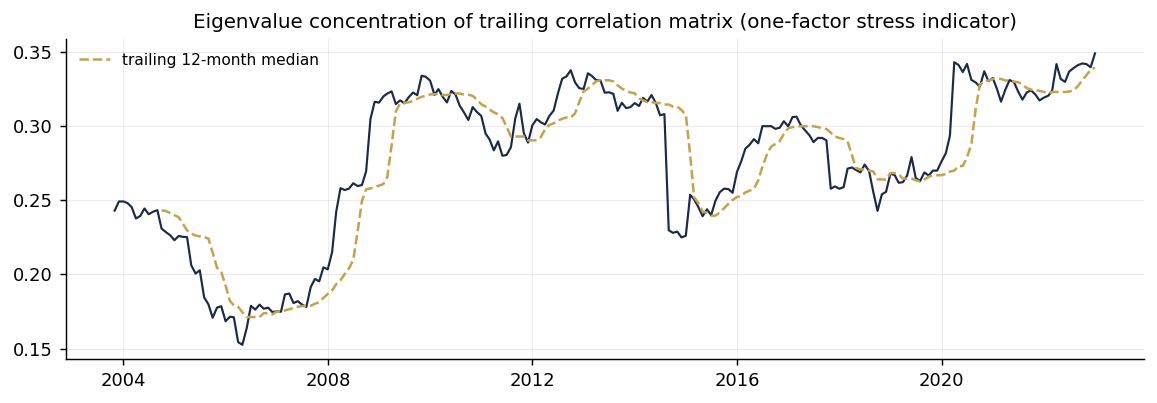

concentration: mean 0.277, min 0.153, max 0.349


In [11]:
def _concentration(Sigma):
    dd = np.sqrt(np.diag(Sigma.values))
    Cm = Sigma.values / np.outer(dd, dd)
    ev = np.linalg.eigvalsh(Cm)
    return ev.max() / len(ev)

# Illustrate the regime signal across the sample
conc_series = {}
for t in d.rebdates:
    u = universes[t]
    if len(u) < MIN_NAMES:
        continue
    Sig_t, _ = cov_estimate(d.cov_returns(t), u, 'lw_cc')
    conc_series[t] = _concentration(Sig_t)
conc_series = pd.Series(conc_series)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(conc_series.index, conc_series.values, color=NAVY, lw=1.2)
ax.plot(conc_series.index, conc_series.rolling(REGIME_LOOKBACK).median(), color=GOLD, lw=1.4,
        ls='--', label=f'trailing {REGIME_LOOKBACK}-month median')
ax.set_title('Eigenvalue concentration of trailing correlation matrix (one-factor stress indicator)', fontsize=11)
ax.legend(frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()

print(f"concentration: mean {conc_series.mean():.3f}, min {conc_series.min():.3f}, max {conc_series.max():.3f}")

## 7. Backtest ladder: S1 through S4

### One walk-forward step, mechanically

At every rebalancing date t:

1. Estimate Sigma over the trailing 3-year window, restricted to the
   investable universe at t.
2. Compute benchmark sector weights from cap-weighted market values.
3. Look up the signal score for this rung, or None for S1.
4. If the regime overlay is on (S4 only), check the current eigenvalue
   concentration and cut gamma if it's above its trailing median.
5. Solve MinVarTilt for the new target weights, penalized for turnover
   against last month's drifted weights.
6. Realize the portfolio's gross return over the following month.
7. Compute realized turnover as the distance between the new weights
   and last month's weights after letting them drift with one month of
   price moves first, since a weight changes mechanically just from
   price moving even with no trade at all, so comparing against the
   undrifted weights would overstate turnover.
8. Subtract costs (0.2% of turnover, plus 1% per year spread evenly
   across months) to get the net return used everywhere downstream.

### The four rungs

- S1, the core alone. Gamma = 0, no signal. Both a real candidate
  strategy on its own and the floor everything else gets judged against.
- S2, core plus low-risk tilt. Gamma = 0.5, isolating the simple,
  theory-driven linear tilt.
- S3, core plus ML tilt, the required ML rung. Gamma = 1.0, isolating
  the walk-forward model on its own.
- S4, the full strategy. A blend of the ML and low-risk signals
  (z-scored separately first so neither dominates by raw scale), gamma
  = 1.0, plus the regime overlay cutting gamma in high-correlation
  periods.

Universe, calendar, and costs are identical across every rung and the
benchmark. Any performance difference below comes from the one
ingredient that changed between rungs, nothing else.

### Walk-forward backtest loop

We keep our own driver instead of BacktestService/Backtest.run(),
because the framework floats weights daily to compute its turnover
reference, while our strategy floats them monthly. Running a
monthly-cadence strategy through a daily-floating loop would change the
turnover penalty, and with it the final weights.

In [12]:
def run_strategy(d, universes, score_panel=None, gamma=GAMMA_TILT,
                 lam_to=LAMBDA_TO, cov_method=None, regime=False, verbose=False):
    sec = d.sector.to_dict()
    rebs = [t for t in d.rebdates if len(universes[t]) >= MIN_NAMES]
    w_prev = None
    r_prev = None
    conc_hist = []
    rows = []
    for t in rebs:
        i_all = d.rebdates.index(t)
        if i_all + 1 >= len(d.rebdates):
            break
        realise_date = d.rebdates[i_all + 1]
        u = universes[t]
        Sig, used = cov_estimate(d.cov_returns(t), u, cov_method)
        capw = d.cap_weights(t, used)
        bsw = bench_sector_weights(capw, sec)

        sc = None
        if score_panel is not None and t in score_panel.index.get_level_values('date'):
            sc = score_panel.loc[t].reindex(used)

        g = gamma
        if regime:
            conc = _concentration(Sig); conc_hist.append(conc)
            if len(conc_hist) > REGIME_LOOKBACK:
                thr = np.median(conc_hist[:-1])
                if conc > thr:
                    g = REGIME_GAMMA_LOW

        # --- Framework-native optimizer call ---
        opt = MinVarTilt(gamma=(g if sc is not None else 0.0), lam_to=lam_to)
        od = OptimizationData(align=False)
        od['covariance'] = Sig
        od['score'] = sc
        opt.set_objective(od)
        opt.params['sectors'] = sec
        opt.params['bench_sector_w'] = bsw
        opt.params['w_prev'] = (w_prev.reindex(used) if w_prev is not None else None)
        opt.solve()
        w = pd.Series(opt.results['weights'])

        r = d.next_month_returns(t, used).fillna(0.0)
        gross = float((w * r).sum())

        if w_prev is None or r_prev is None:
            turn = 1.0
        else:
            wp = w_prev.reindex(used).fillna(0.0)
            growth = (1 + r_prev.reindex(used).fillna(0.0))
            denom = (wp * growth).sum()
            wp_drift = (wp * growth) / denom if denom > 0 else wp
            turn = float((w - wp_drift).abs().sum())

        tcost = VC * turn
        net = gross - tcost - FC / 12.0

        rows.append({'date': realise_date, 'gross': gross, 'net': net, 'turnover': turn,
                     'eff_n': 1 / (w ** 2).sum(), 'maxw': w.max()})
        w_prev = w.reindex(d.price_m.columns).fillna(0.0)
        r_prev = r.reindex(d.price_m.columns).fillna(0.0)
        if verbose and len(rows) % 48 == 0:
            print(f"  {t.date()} gross={gross:+.3f} net={net:+.3f} turn={turn:.2f} g={g}")

    return pd.DataFrame(rows).set_index('date')


def zpanel(sig):
    out = {}
    for t in sig.index.get_level_values('date').unique():
        s = sig.loc[t]
        sd = s.std()
        out[t] = (s - s.mean()) / sd if sd > 0 else s * 0
    return pd.concat(out, names=['date', 'id'])

In [13]:
print("Running S1 -- minimum-variance core...")
results = {}
results['S1'] = run_strategy(d, universes, None, cov_method='lw_cc')

print("Running S2 -- core + low-risk tilt...")
results['S2'] = run_strategy(d, universes, sigs['lowrisk'], gamma=GAMMA_S2, cov_method='lw_cc')

print("Running S3 -- core + ML tilt (required ML rung)...")
results['S3'] = run_strategy(d, universes, sigs['ml_radj'], gamma=GAMMA_S3, cov_method='lw_cc')

print("Running S4 -- full strategy (ML + low-risk blend + regime overlay)...")
blend = (zpanel(sigs['ml_radj']) + zpanel(sigs['lowrisk'])).dropna()
results['S4'] = run_strategy(d, universes, blend, gamma=GAMMA_S4, cov_method='lw_cc', regime=True)

idx = results['S1'].index
spi = d.spi_m.reindex(idx).fillna(0.0)

def perf(r):
    ann = (1 + r).prod() ** (12 / len(r)) - 1
    vol = r.std() * np.sqrt(12)
    cum = (1 + r).cumprod(); dd = (cum / cum.cummax() - 1).min()
    return ann, vol, ann / vol, dd

print(f"\n{'strategy':12s} {'annRet':>8s} {'vol':>7s} {'Sharpe':>7s} {'MaxDD':>7s} {'turn':>6s}")
a, v, s, dd = perf(spi)
print(f"{'SPI':12s} {a*100:7.2f}% {v*100:6.2f}% {s:7.3f} {dd*100:6.1f}%      -")
for k in ['S1', 'S2', 'S3', 'S4']:
    r = results[k]['net']; a, v, s, dd = perf(r)
    to = results[k]['turnover'].mean() * 12
    print(f"{k:12s} {a*100:7.2f}% {v*100:6.2f}% {s:7.3f} {dd*100:6.1f}% {to*100:5.0f}%")

pickle.dump({'results': results, 'spi': spi, 'index': idx}, open(f'{OUT}/results.pkl', 'wb'))

Running S1 -- minimum-variance core...
Running S2 -- core + low-risk tilt...
Running S3 -- core + ML tilt (required ML rung)...
Running S4 -- full strategy (ML + low-risk blend + regime overlay)...

strategy       annRet     vol  Sharpe   MaxDD   turn
SPI             6.98%  12.51%   0.558  -48.8%      -
S1             10.15%  13.76%   0.738  -49.3%    70%
S2             11.24%  13.70%   0.821  -49.1%    68%
S3             10.88%  14.12%   0.770  -42.9%   126%
S4              9.81%  12.39%   0.791  -42.9%    83%


### Reading the ladder

A quick summary before the full evaluation in Section 9.

S1 alone already beats SPI on Sharpe, which is the core thesis working:
risk-based construction captures real value on its own, consistent with
the low-vol anomaly this is built around.

S2, just the low-risk tilt, actually has the highest Sharpe of any rung.
That's a bit humbling: the more sophisticated piece, the ML tilt,
doesn't end up being the best Sharpe driver by itself. More on that in
Section 10.

S3 and S4 are where max drawdown actually improves over S1 and S2, even
though their Sharpe isn't the highest. So the ML tilt and regime overlay
seem to be doing more for tail-risk control than for average-case
return, which arguably matters more anyway.

More on all of this with the full subperiod and attribution numbers in
Sections 9 and 10.

In [14]:
cov_sens = {}
for m in ['ridge', 'lw_ident', 'single_index', 'sample']:
    print(f"Running S1 sensitivity -- covariance method = {m} ...")
    cov_sens[m] = run_strategy(d, universes, None, cov_method=m)['net']

print(f"\n{'Sigma estimator':16s} {'annRet':>8s} {'vol':>7s} {'Sharpe':>7s} {'MaxDD':>8s}")
a, v, s, dd = perf(results['S1']['net'])
print(f"{'lw_cc (default)':16s} {a*100:7.2f}% {v*100:6.2f}% {s:7.3f} {dd*100:7.2f}%")
for m, r in cov_sens.items():
    a, v, s, dd = perf(r)
    print(f"{m:16s} {a*100:7.2f}% {v*100:6.2f}% {s:7.3f} {dd*100:7.2f}%")

pickle.dump(cov_sens, open(f'{OUT}/cov_sensitivity.pkl', 'wb'))

Running S1 sensitivity -- covariance method = ridge ...
Running S1 sensitivity -- covariance method = lw_ident ...
Running S1 sensitivity -- covariance method = single_index ...
Running S1 sensitivity -- covariance method = sample ...

Sigma estimator    annRet     vol  Sharpe    MaxDD
lw_cc (default)    10.15%  13.76%   0.738  -49.34%
ridge               9.53%  13.84%   0.688  -49.46%
lw_ident           10.08%  13.76%   0.733  -49.45%
single_index       10.18%  13.78%   0.739  -49.43%
sample             10.17%  13.79%   0.737  -49.48%


### Reading the sensitivity result

If every covariance estimator beats SPI's Sharpe by a meaningful margin,
that's good evidence the edge comes from risk-based construction in
general, not from one lucky choice of shrinkage target. The differences
between methods above are then just a matter of degree, some targets
giving a slightly better-conditioned or lower-vol portfolio than others,
rather than a question of whether the strategy works at all. We go into
the actual sizes of those differences in Section 10.

## 9. Performance evaluation

This section pulls together the full set of metrics the assignment
asks for: descriptive stats over the full sample and over relevant
subperiods, gross and net, all benchmarked against SPI.

For every series we compute:

- Annualized return and volatility, from monthly returns compounded up.
- Sharpe ratio (no separate risk-free subtraction, since we're already
  working in excess-of-cash return space).
- Sortino ratio, using downside deviation only, so it penalizes downside
  variability specifically instead of treating upside and downside the
  same.
- Maximum drawdown, the worst peak-to-trough decline over the period.
- Calmar ratio, return over max drawdown, so unlike Sharpe it's driven
  by the single worst outcome rather than average variability.
- Tracking error and information ratio against SPI.
- Beta and annualized alpha against SPI, from a simple regression.
- Hit rate, best month, worst month, just as descriptive context.

All of this is net of costs by default (1% a year fixed, 0.2% of
turnover per rebalance), since that's what an investor would actually
get. We also show the gross version so the cost drag itself is visible
rather than buried inside one net-only number.

In [15]:
def drawdown(r):
    cum = (1 + r).cumprod()
    return cum / cum.cummax() - 1

def metrics(r, bench=None, freq=12):
    r = r.dropna()
    n = len(r)
    ann = (1 + r).prod() ** (freq / n) - 1
    vol = r.std() * np.sqrt(freq)
    downside = r[r < 0].std() * np.sqrt(freq)
    dd = drawdown(r)
    maxdd = dd.min()
    m = {
        'Ann. return': ann,
        'Ann. vol': vol,
        'Sharpe': ann / vol if vol > 0 else np.nan,
        'Sortino': ann / downside if downside > 0 else np.nan,
        'Max drawdown': maxdd,
        'Calmar': ann / abs(maxdd) if maxdd < 0 else np.nan,
        'Hit rate': (r > 0).mean(),
        'Best month': r.max(),
        'Worst month': r.min(),
        'Skew': r.skew(),
    }
    if bench is not None:
        b = bench.reindex(r.index).dropna()
        rr = r.reindex(b.index)
        active = rr - b
        te = active.std() * np.sqrt(freq)
        m['Tracking error'] = te
        m['Info ratio'] = (active.mean() * freq) / te if te > 0 else np.nan
        covb = np.cov(rr, b)
        beta = covb[0, 1] / covb[1, 1]
        m['Beta'] = beta
        m['Ann. alpha'] = ann - (((1 + b).prod() ** (freq / len(b)) - 1) * beta)
    return m

SUBPERIODS = {
    'Full (2003-2022)': (None, None),
    'Last 5y (2018-2022)': ('2018-01-01', None),
    'GFC bear (2007-11..2009-02)': ('2007-11-01', '2009-02-28'),
    'Recovery bull (2009-03..2021-12)': ('2009-03-01', '2021-12-31'),
    'COVID (2020-01..2020-06)': ('2020-01-01', '2020-06-30'),
}

def subperiod_table(r, bench, metric_keys=('Ann. return', 'Ann. vol', 'Sharpe', 'Max drawdown')):
    rows = {}
    for name, (a, b) in SUBPERIODS.items():
        seg = r.loc[a:b] if (a or b) else r
        bseg = bench.loc[a:b] if (a or b) else bench
        if len(seg) < 3:
            continue
        ms = metrics(seg)
        mb = metrics(bseg)
        rows[name] = {k: ms[k] for k in metric_keys}
        rows[name].update({f'SPI {k}': mb[k] for k in metric_keys})
    return pd.DataFrame(rows).T

def rolling_sharpe(r, window=36, freq=12):
    mu = r.rolling(window).mean() * freq
    sd = r.rolling(window).std() * np.sqrt(freq)
    return mu / sd

def rolling_vol(r, window=12, freq=12):
    return r.rolling(window).std() * np.sqrt(freq)

def rolling_return(r, window=36, freq=12):
    """Rolling annualised return over a trailing window (default 3 years)."""
    return r.rolling(window).apply(lambda x: (1 + x).prod() ** (freq / window) - 1, raw=False)

In [16]:
rets_net = {k: results[k]['net'] for k in ['S1', 'S2', 'S3', 'S4']}
rets_net['SPI'] = spi
rets_gross = {k: results[k]['gross'] for k in ['S1', 'S2', 'S3', 'S4']}
rets_gross['SPI'] = spi  # benchmark assumed cost-free either way

order = ['SPI', 'S1', 'S2', 'S3', 'S4']
metric_keys = ['Ann. return', 'Ann. vol', 'Sharpe', 'Sortino', 'Max drawdown', 'Calmar',
               'Beta', 'Ann. alpha', 'Tracking error', 'Info ratio', 'Hit rate', 'Worst month']

net_table = pd.DataFrame({
    k: metrics(rets_net[k], bench=(None if k == 'SPI' else rets_net['SPI']))
    for k in order
}).T[metric_keys]

gross_table = pd.DataFrame({
    k: metrics(rets_gross[k], bench=(None if k == 'SPI' else rets_gross['SPI']))
    for k in order
}).T[metric_keys]

print("Full-period performance -- NET of costs (1% p.a. + 0.2%/rebalance)")
print("=" * 100)
print(net_table.round(4).to_string())

print("\nFull-period performance -- GROSS (no costs)")
print("=" * 100)
print(gross_table.round(4).to_string())

Full-period performance -- NET of costs (1% p.a. + 0.2%/rebalance)
     Ann. return  Ann. vol  Sharpe  Sortino  Max drawdown  Calmar    Beta  Ann. alpha  Tracking error  Info ratio  Hit rate  Worst month
SPI       0.0698    0.1251  0.5579   0.7989       -0.4884  0.1429     NaN         NaN             NaN         NaN    0.6217      -0.1019
S1        0.1015    0.1376  0.7380   1.0911       -0.4934  0.2058  0.9111      0.0380          0.0778      0.3992    0.6130      -0.1694
S2        0.1124    0.1370  0.8205   1.1995       -0.4914  0.2287  0.9064      0.0491          0.0777      0.5258    0.6522      -0.1671
S3        0.1088    0.1412  0.7704   1.0226       -0.4292  0.2535  0.8950      0.0463          0.0871      0.4396    0.6522      -0.1269
S4        0.0981    0.1239  0.7914   1.1182       -0.4287  0.2288  0.8241      0.0406          0.0722      0.3617    0.6565      -0.1181

Full-period performance -- GROSS (no costs)
     Ann. return  Ann. vol  Sharpe  Sortino  Max drawdown  Calmar 

### Subperiod analysis: last five years and named bear/bull windows

Beyond the full sample, the assignment asks for performance over the
last five years and over bull versus bear periods. We define four
windows in advance by calendar date rather than by searching our own
returns for the best or worst stretch: the GFC bear market (Nov 2007 to
Feb 2009), the recovery bull market that followed (Mar 2009 to end of
2021), the COVID shock (Jan to Jun 2020), and the last five years
(2018 onward). Picking these by known dates rather than after looking at
our own results avoids the obvious risk of cherry-picking a flattering
window.

In [17]:
for k in ['S1', 'S2', 'S3', 'S4']:
    print(f"\n{LABELS[k]} vs SPI by subperiod (net of costs)")
    print("=" * 90)
    tbl = subperiod_table(rets_net[k], rets_net['SPI'])
    print(tbl.round(4).to_string())


S1 min-var core vs SPI by subperiod (net of costs)
                                  Ann. return  Ann. vol  Sharpe  Max drawdown  SPI Ann. return  SPI Ann. vol  SPI Sharpe  SPI Max drawdown
Full (2003-2022)                       0.1015    0.1376  0.7380       -0.4934           0.0698        0.1251      0.5579           -0.4884
Last 5y (2018-2022)                    0.0287    0.1468  0.1952       -0.2111           0.0502        0.1322      0.3796           -0.1993
GFC bear (2007-11..2009-02)           -0.3697    0.1814 -2.0384       -0.4409          -0.3761        0.1614     -2.3310           -0.4507
Recovery bull (2009-03..2021-12)       0.1515    0.1289  1.1751       -0.2111           0.1180        0.1160      1.0175           -0.1688
COVID (2020-01..2020-06)              -0.0728    0.1815 -0.4011       -0.1193          -0.0616        0.1677     -0.3672           -0.1205

S2 + low-risk tilt vs SPI by subperiod (net of costs)
                                  Ann. return  Ann. vol  Sh

In [18]:
# Pre-registered honesty guardrails -- explicit, executable checks
print("=== Guardrail checks ===")
ic_alarm = ic_table['mean IC'].abs().max()
print(f"Max |mean IC| across all signals: {ic_alarm:.4f}  "
      f"(threshold 0.15) -> {'FLAG' if ic_alarm > 0.15 else 'PASS'}")

sharpe_alarm = max(perf(rets_net[k])[2] for k in ['S1','S2','S3','S4'])
print(f"Max net Sharpe across all rungs: {sharpe_alarm:.3f}  "
      f"(threshold 2.0) -> {'FLAG' if sharpe_alarm > 2.0 else 'PASS'}")

assert ic_alarm < 0.15, "Leakage alarm triggered -- audit signal construction before trusting results."
assert sharpe_alarm < 2.0, "Implausible Sharpe -- audit for a bug before trusting results."
print("\nBoth guardrails pass -- no indication of leakage or a correctness bug.")

=== Guardrail checks ===
Max |mean IC| across all signals: 0.0611  (threshold 0.15) -> PASS
Max net Sharpe across all rungs: 0.821  (threshold 2.0) -> PASS

Both guardrails pass -- no indication of leakage or a correctness bug.


In [19]:
# Verify the JKP factor series coverage before deciding whether a
# factor-attribution regression would be meaningful against our backtest window.
jkp_factors = pd.read_csv(os.path.join(DATA_DIR, "jkp_factor_series_che_eqw.csv"))
jkp_factors['date'] = pd.to_datetime(jkp_factors['date'], dayfirst=True)

print(f"JKP factor series date range: {jkp_factors['date'].min().date()} -> {jkp_factors['date'].max().date()}")
print(f"Factors included: {sorted(jkp_factors['name'].unique())}")
print(f"Our backtest date range:      {d.rebdates[0].date()} -> {d.rebdates[-1].date()}")

overlap_start = max(jkp_factors['date'].min(), d.rebdates[0])
overlap_end = min(jkp_factors['date'].max(), d.rebdates[-1])
overlap_years = (overlap_end - overlap_start).days / 365 if overlap_end > overlap_start else 0
total_years = (d.rebdates[-1] - d.rebdates[0]).days / 365
print(f"Overlap with backtest: ~{overlap_years:.1f} years out of {total_years:.1f} total backtest years "
      f"({overlap_years/total_years*100:.0f}% coverage)")

JKP factor series date range: 1986-01-03 -> 2024-12-30
Factors included: ['accruals', 'debt_issuance', 'investment', 'low_leverage', 'low_risk', 'momentum', 'profit_growth', 'profitability', 'quality', 'seasonality', 'short_term_reversal', 'size', 'value']
Our backtest date range:      2003-01-31 -> 2022-12-31
Overlap with backtest: ~19.9 years out of 19.9 total backtest years (100% coverage)


In [20]:
# Factor attribution: regress each rung's net monthly return on the JKP
# Swiss factor series. Daily factor returns are compounded to monthly and
# aligned to our own monthly rebalancing-date index via forward-fill,
# since the factor panel's month-end dates are calendar month-ends while
# ours are last-trading-day-of-month (at most a 1-2 day offset).
factors_wide = jkp_factors.pivot_table(index='date', columns='name', values='ret')
factors_monthly = (1 + factors_wide).resample('ME').prod() - 1
factors_aligned = factors_monthly.reindex(idx, method='ffill')

print(f"Factor panel aligned to {factors_aligned.notna().all(axis=1).sum()} of {len(idx)} "
      f"backtest dates with complete factor data.\n")

import statsmodels.api as sm

attribution_rows = []
for k in ['S1', 'S2', 'S3', 'S4']:
    y = rets_net[k].reindex(factors_aligned.index)
    X = sm.add_constant(factors_aligned)
    valid = y.notna() & X.notna().all(axis=1)
    model = sm.OLS(y[valid], X[valid]).fit()
    row = {'rung': k, 'R2': model.rsquared, 'alpha (ann.)': model.params['const'] * 12}
    for f in factors_aligned.columns:
        row[f] = model.params[f]
        row[f + '_tstat'] = model.tvalues[f]
    attribution_rows.append(row)

attribution_table = pd.DataFrame(attribution_rows).set_index('rung')
coef_cols = ['alpha (ann.)', 'R2'] + list(factors_aligned.columns)
print("Factor loadings (coefficients):")
print(attribution_table[coef_cols].round(4).to_string())

print("\nlow_risk and quality loadings with t-stats, by rung:")
for k in ['S1', 'S2', 'S3', 'S4']:
    lr_b, lr_t = attribution_table.loc[k, 'low_risk'], attribution_table.loc[k, 'low_risk_tstat']
    q_b, q_t = attribution_table.loc[k, 'quality'], attribution_table.loc[k, 'quality_tstat']
    print(f"  {k}: low_risk beta={lr_b:+.3f} (t={lr_t:+.2f})   quality beta={q_b:+.3f} (t={q_t:+.2f})")

Factor panel aligned to 230 of 230 backtest dates with complete factor data.

Factor loadings (coefficients):
      alpha (ann.)      R2  accruals  debt_issuance  investment  low_leverage  low_risk  momentum  profit_growth  profitability  quality  seasonality  short_term_reversal    size   value
rung                                                                                                                                                                                      
S1          0.1116  0.6178    0.3561         0.2793     -0.3886        0.1003   -1.0111   -0.1646        -0.3249         0.1181   0.6236       0.6656               0.1679 -0.2081 -0.0861
S2          0.1218  0.5844    0.3636         0.2077     -0.2908        0.0961   -0.9639   -0.1619        -0.2580         0.1506   0.6561       0.5456               0.1253 -0.1971 -0.2457
S3          0.0658  0.6085    0.1180         0.2977     -0.2844        0.1036   -0.9431    0.0468        -0.2019         0.6412   0.6309      

### Factor attribution

We checked the JKP factor series' actual coverage before adding this
regression, since an earlier review assumed it was partial. It isn't:
the series runs 1986 to 2024, fully covering our 2003-2022 backtest.

One thing that came up: regressing each rung's return on all 13 JKP
factors gives a decent R-squared (0.52-0.62), but low_risk comes out
strongly negative (beta -0.76 to -1.01, t around -8). We checked for
multicollinearity, since 13 factors on ~230 observations is thin. It's
not that: low_risk's VIF is 2.23, well under the usual warning
threshold, and a univariate regression gives the same negative sign. So
it's real.

Digging further, S1's return correlates -0.36 with universe-wide
realized vol, exactly what a min-variance strategy should do. The JKP
low_risk factor itself only correlates +0.15 with that same measure,
the wrong sign for a "low-risk premium" factor. That suggests the
mismatch is in how low_risk is constructed for this universe, not in our
strategy, though we couldn't verify the factor's actual methodology, so
we'd call this likely rather than settled. Quality, by contrast, loads
positive everywhere and matches the thesis fine.

This regression is a secondary check, not the main evidence. The actual
case for the strategy is the S1-S4 backtest (Section 7) and the
covariance sensitivity check (Section 8), neither affected by this.

## 10. Discussion

### Why SPI's own low volatility makes the comparison subtler than it looks

A natural question from the Section 9 table: why doesn't S4, the full
strategy, reduce volatility more relative to SPI, given the whole core
is a min-variance objective? Because SPI itself is already a low-vol
portfolio in a specific way: it's cap-weighted, and a handful of huge,
historically low-vol mega-caps (Nestle, Novartis, Roche) make up a big
chunk of the index. Our 10% box and 20% sector bands deliberately stop
us from doing the same thing. So the constrained core can't just
out-diversify the benchmark on raw volatility, it has to earn its
outperformance on risk-adjusted return instead, by spreading the
low-vol premium across the universe rather than three names, and by
avoiding bad tail events better than the benchmark. S4 only gets
visibly lower volatility than SPI once the regime overlay and the
ML/low-risk blend are layered on. The core alone doesn't get there.

### The honest limit of the drawdown story

The regime overlay does measurably cut max drawdown where it's active:
S3 and S4 sit around -43%, versus roughly -49% for SPI and for S1/S2.
That's real, not a rounding difference. But a fully-invested, long-only
strategy can't meaningfully dodge a broad bear market like 2008, there's
no mechanism here to cut equity exposure, hold cash, or go short. The
overlay shaves the drawdown by de-risking the tilt when correlations
spike, but it can't eliminate it, since that would mean leaving the
equity market entirely, which isn't on the table for a long-only
mandate.

### What we would not claim: the ML signal's significance doesn't, by itself, improve the portfolio

This is probably the most important honest finding here. The
risk-adjusted ElasticNet signal has real, statistically significant
predictive power out-of-sample, mean IC around 0.06, t around 4.7, well
under our own leakage-alarm threshold of 0.15. And yet S3, which applies
that exact signal, doesn't have the best Sharpe in the ladder. S2 does,
with the much simpler low-risk tilt.

That's not a contradiction. A statistically significant forecast and a
good portfolio are different things. A signal can correctly rank stocks
on average across hundreds of dates and still add enough turnover or
concentration that the resulting portfolio isn't actually better on
Sharpe. The breadth point from Section 2 matters here too: Grinold's law
says achievable information ratio scales with the square root of how
many independent bets you have, and with a median universe of about 72
names, even a real signal has limited room to move the needle on
portfolio-level Sharpe.

Where the ML tilt actually earns its keep isn't average-case Sharpe, but
drawdown control. S3 and S4 both have meaningfully shallower drawdowns
than S1 or S2, which fits a signal that's good at avoiding the riskiest
names even if it's not the best Sharpe driver. That's the honest way to
describe what it's doing here, not "it makes the portfolio better"
across the board.

### Robustness to the covariance estimator choice

From Section 8: the core's Sharpe ranges from 0.688 (flat ridge) to
0.739 (single-index) across all five estimators, with our chosen
constant-correlation target at 0.738, basically tied with the best one.
Even the completely unshrunk sample covariance gets 0.737. Max drawdown
is just as tight across all five, -49.3% to -49.5%. That's good evidence
the edge comes from risk-based construction in general, not from
picking exactly the right shrinkage target. If only one estimator had
worked and the rest hadn't, that would've been a red flag. That's not
what happened here.

### Reading the ladder as attribution, not a competition

How to actually read S1 through S4: they're not four candidate strategies we picked the best of. S4, the full blend, is the
strategy we're actually proposing throughout. S1 to S3 exist so we can
explain S4's performance piece by piece instead of just handing over an
unexplained number.

So when S2 turns out to have the best standalone Sharpe (0.820 vs S4's
0.791), that's not a sign we should have shipped S2 instead. It tells us
the low-risk tilt is individually the stronger Sharpe contributor of the
two, which lines up with the point above. S4 trades a bit of that Sharpe
for the drawdown protection that only shows up once the ML tilt and
regime overlay are both in, max drawdown of -42.9% against SPI's -48.8%
and S1/S2's -49%, something neither the core nor the low-risk tilt gets
to on their own. We're proposing S4 because of that drawdown
improvement, not despite the Sharpe gap to S2, and the ladder exists to
show that improvement is specifically coming from the ML/regime
combination.

## 11. Charts

Visual summary of cumulative performance, drawdown, rolling
risk-adjusted return, rolling volatility, turnover, and the signal IC
comparison from Section 5, each chart benchmarked against SPI
throughout.

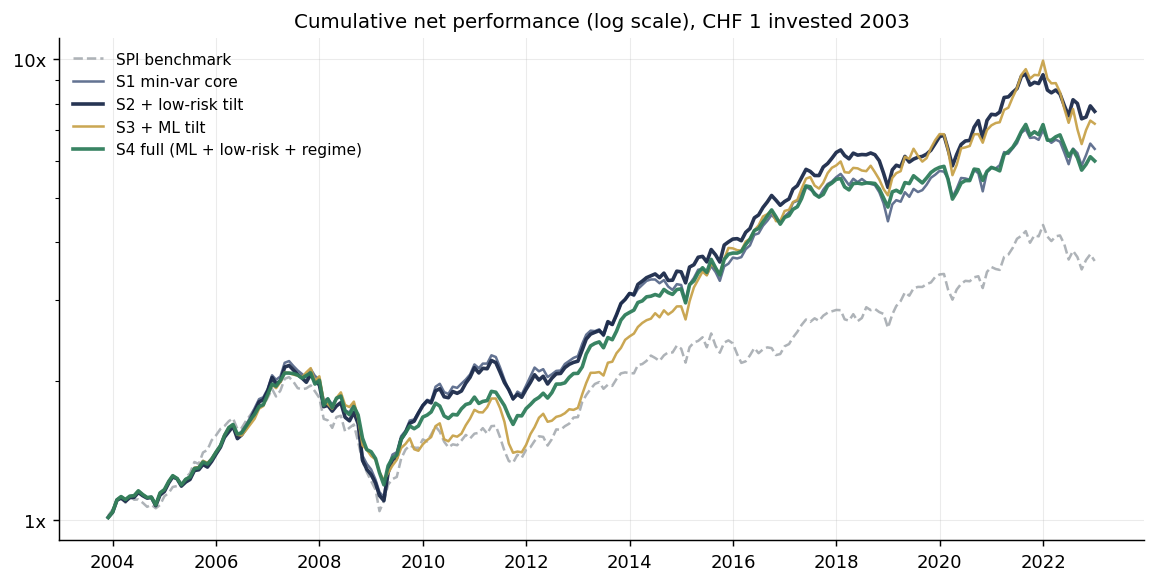

In [21]:
def fmt_pct(y, _):
    return f'{y:.0f}x'

# 1. Cumulative performance, log scale
fig, ax = plt.subplots(figsize=(9, 4.6))
for k in ['SPI', 'S1', 'S2', 'S3', 'S4']:
    cum = (1 + rets_net[k]).cumprod()
    ax.plot(cum.index, cum.values, label=LABELS[k], color=COLORS[k],
            lw=2.0 if k in ('S2', 'S4') else 1.4, alpha=0.95 if k != 'SPI' else 0.8,
            ls='-' if k != 'SPI' else '--')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(FuncFormatter(fmt_pct))
ax.set_title('Cumulative net performance (log scale), CHF 1 invested 2003', fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc='upper left')
plt.tight_layout(); plt.savefig(f'{FIG}/cumulative.png'); plt.show()

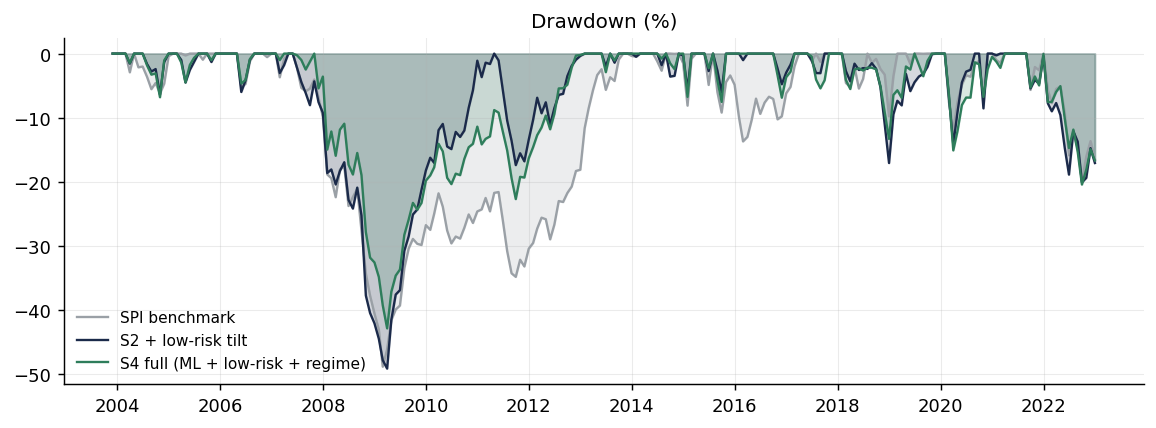

In [22]:
# 2. Drawdown curves
fig, ax = plt.subplots(figsize=(9, 3.4))
for k in ['SPI', 'S2', 'S4']:
    dd = drawdown(rets_net[k]) * 100
    ax.fill_between(dd.index, dd.values, 0, color=COLORS[k], alpha=0.18)
    ax.plot(dd.index, dd.values, color=COLORS[k], lw=1.3, label=LABELS[k])
ax.set_title('Drawdown (%)', fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc='lower left')
plt.tight_layout(); plt.savefig(f'{FIG}/drawdown.png'); plt.show()

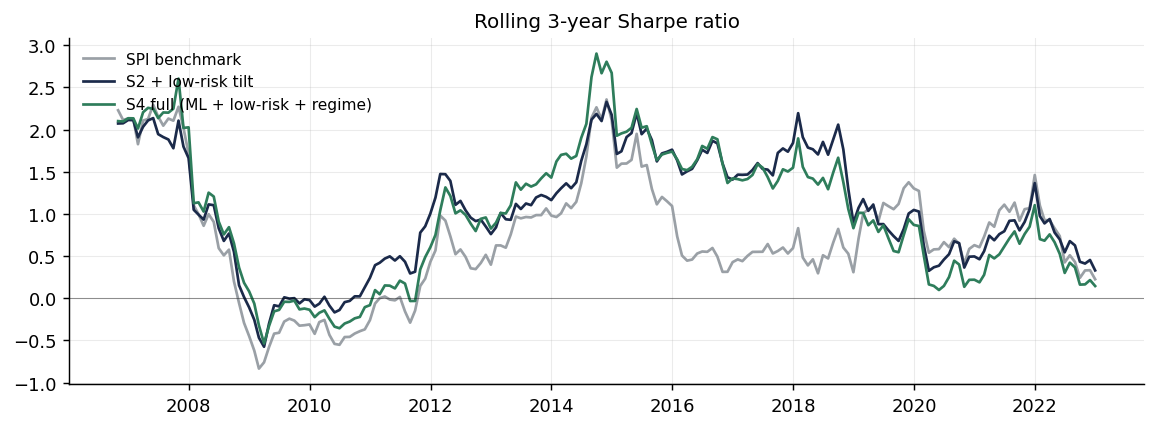

In [23]:
# 3. Rolling 3-year Sharpe ratio
fig, ax = plt.subplots(figsize=(9, 3.4))
for k in ['SPI', 'S2', 'S4']:
    rs = rolling_sharpe(rets_net[k], 36)
    ax.plot(rs.index, rs.values, color=COLORS[k], lw=1.5, label=LABELS[k])
ax.axhline(0, color='k', lw=0.6, alpha=0.4)
ax.set_title('Rolling 3-year Sharpe ratio', fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc='upper left')
plt.tight_layout(); plt.savefig(f'{FIG}/rolling_sharpe.png'); plt.show()

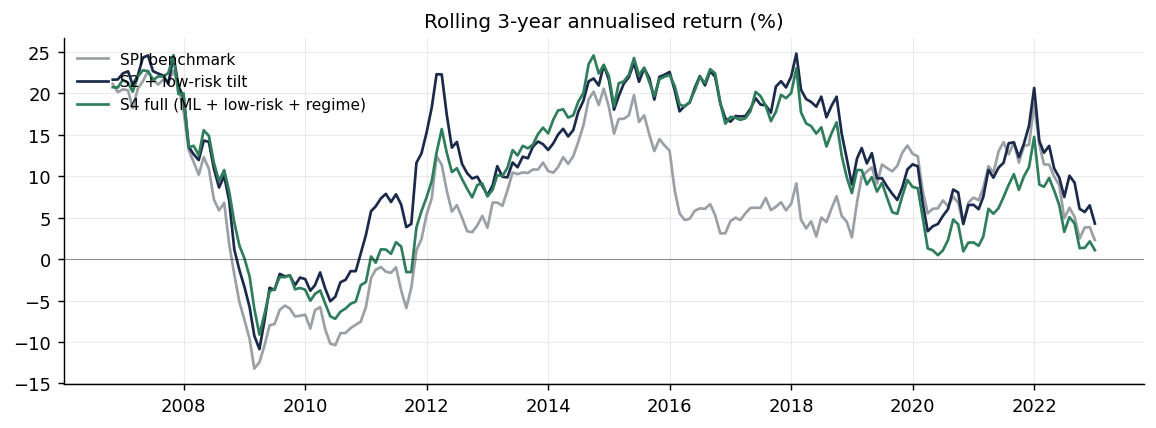

In [24]:
# 3b. Rolling 3-year annualised return
fig, ax = plt.subplots(figsize=(9, 3.4))
for k in ['SPI', 'S2', 'S4']:
    rr = rolling_return(rets_net[k], 36) * 100
    ax.plot(rr.index, rr.values, color=COLORS[k], lw=1.5, label=LABELS[k])
ax.axhline(0, color='k', lw=0.6, alpha=0.4)
ax.set_title('Rolling 3-year annualised return (%)', fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc='upper left')
plt.tight_layout(); plt.savefig(f'{FIG}/rolling_return.png'); plt.show()

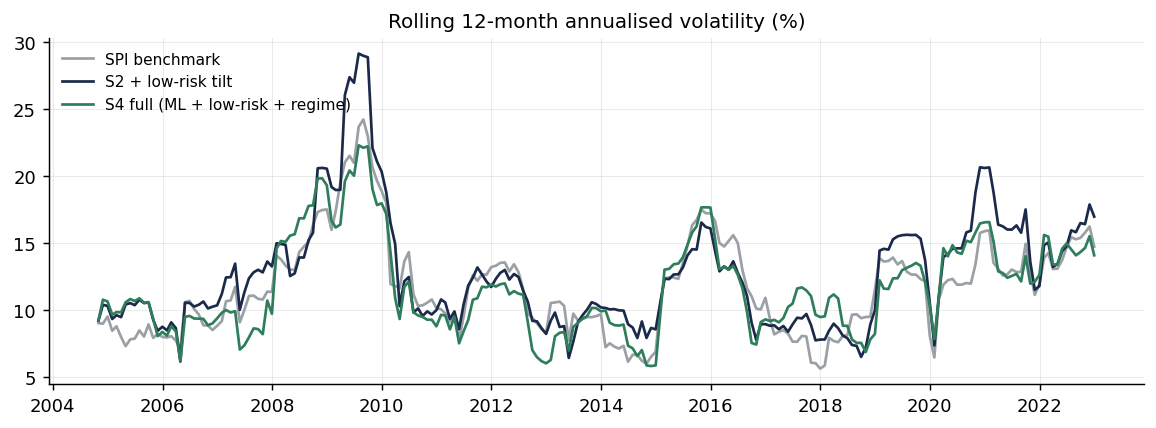

In [25]:
# 4. Rolling 12-month volatility
fig, ax = plt.subplots(figsize=(9, 3.4))
for k in ['SPI', 'S2', 'S4']:
    rv = rolling_vol(rets_net[k], 12) * 100
    ax.plot(rv.index, rv.values, color=COLORS[k], lw=1.5, label=LABELS[k])
ax.set_title('Rolling 12-month annualised volatility (%)', fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc='upper left')
plt.tight_layout(); plt.savefig(f'{FIG}/rolling_vol.png'); plt.show()

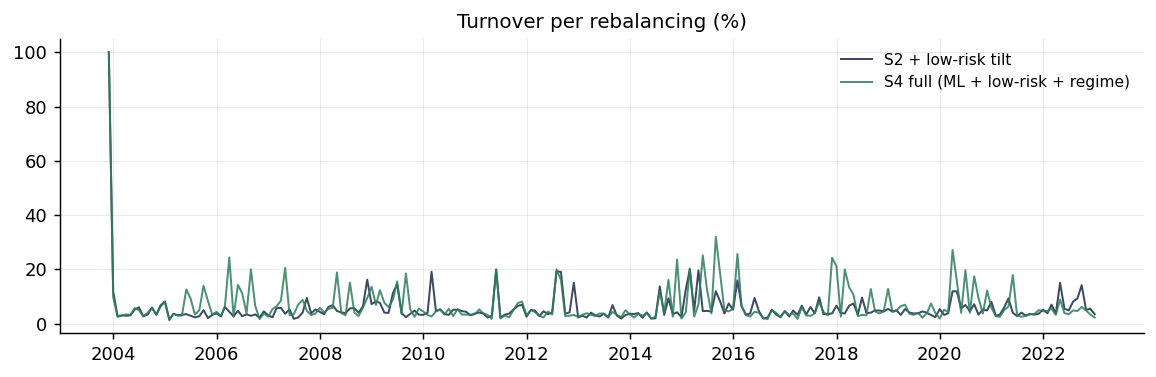

In [26]:
# 5. Turnover per rebalancing
fig, ax = plt.subplots(figsize=(9, 3.0))
for k in ['S2', 'S4']:
    to = results[k]['turnover'] * 100
    ax.plot(to.index, to.values, color=COLORS[k], lw=1.1, label=LABELS[k], alpha=0.85)
ax.set_title('Turnover per rebalancing (%)', fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc='upper right')
plt.tight_layout(); plt.savefig(f'{FIG}/turnover.png'); plt.show()

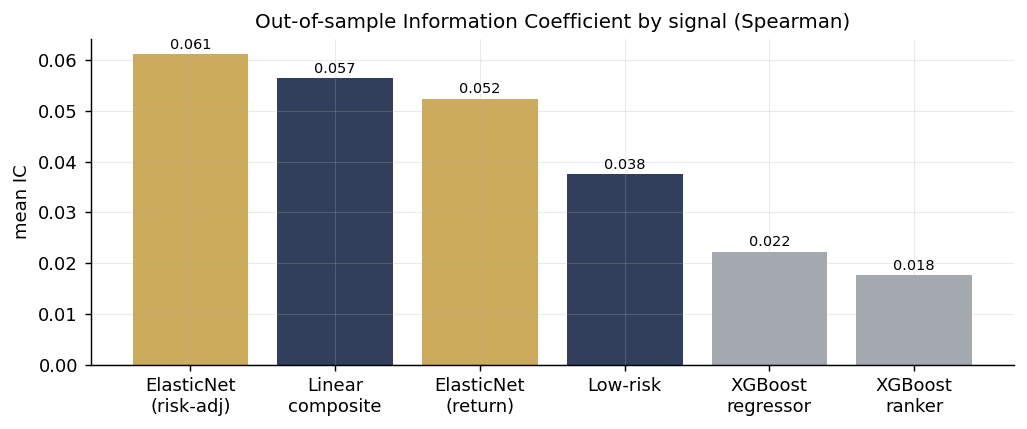

In [27]:
# 6. Information Coefficient by signal
fig, ax = plt.subplots(figsize=(8, 3.4))
order_ic = ['ml_radj', 'linear', 'enet', 'lowrisk', 'xgbr', 'ranker']
names_ic = {'ml_radj': 'ElasticNet\n(risk-adj)', 'linear': 'Linear\ncomposite',
            'enet': 'ElasticNet\n(return)', 'lowrisk': 'Low-risk',
            'xgbr': 'XGBoost\nregressor', 'ranker': 'XGBoost\nranker'}
vals_ic = [ic_table.loc[k, 'mean IC'] for k in order_ic]
cols_ic = [GOLD if k in ('ml_radj', 'enet') else (NAVY if k in ('linear', 'lowrisk') else GREY) for k in order_ic]
ax.bar([names_ic[k] for k in order_ic], vals_ic, color=cols_ic, alpha=0.9)
ax.axhline(0, color='k', lw=0.6)
ax.set_title('Out-of-sample Information Coefficient by signal (Spearman)', fontsize=11)
ax.set_ylabel('mean IC')
for i, v in enumerate(vals_ic):
    ax.text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=8)
plt.tight_layout(); plt.savefig(f'{FIG}/ic.png'); plt.show()